In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import MinMaxScaler  # correct import for scaling


In [3]:
from google.colab import files
uploaded = files.upload()

Saving worldometer_coronavirus_daily_data.csv to worldometer_coronavirus_daily_data.csv


In [9]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("worldometer_coronavirus_daily_data.csv")

# Display the first few rows
df.head()


,date,country,cumulative_total_cases,daily_new_cases,active_cases,cumulative_total_deaths,daily_new_deaths
0,2020-2-15,Afghanistan,0.0,NaN,0.0,0.0,NaN
1,2020-2-16,Afghanistan,0.0,NaN,0.0,0.0,NaN
2,2020-2-17,Afghanistan,0.0,NaN,0.0,0.0,NaN
3,2020-2-18,Afghanistan,0.0,NaN,0.0,0.0,NaN
4,2020-2-19,Afghanistan,0.0,NaN,0.0,0.0,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184787 entries, 0 to 184786
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   date                     184787 non-null  object 
 1   country                  184787 non-null  object 
 2   cumulative_total_cases   184787 non-null  float64
 3   daily_new_cases          174329 non-null  float64
 4   active_cases             166747 non-null  float64
 5   cumulative_total_deaths  178227 non-null  float64
 6   daily_new_deaths         157850 non-null  float64
dtypes: float64(5), object(2)
memory usage: 9.9+ MB


In [11]:
df.describe()

,cumulative_total_cases,daily_new_cases,active_cases,cumulative_total_deaths,daily_new_deaths
count,1.847870e+05,174329.000000,1.667470e+05,1.782270e+05,157850.000000
mean,7.251089e+05,2987.633285,6.239283e+04,1.388600e+04,39.831834
std,3.681471e+06,17803.232663,3.955641e+05,6.049521e+04,181.102770
min,0.000000e+00,-322.000000,-1.432100e+04,0.000000e+00,-39.000000
25%,1.099000e+03,0.000000,6.000000e+01,2.400000e+01,0.000000
50%,1.775600e+04,58.000000,1.386000e+03,3.040000e+02,1.000000
75%,2.238085e+05,728.000000,1.462050e+04,4.111000e+03,12.000000
max,8.420947e+07,909610.000000,1.793543e+07,1.026646e+06,5093.000000


In [12]:
df.isnull().sum()

,0
date,0
country,0
cumulative_total_cases,0
daily_new_cases,10458
active_cases,18040
cumulative_total_deaths,6560
daily_new_deaths,26937


In [14]:

# Rename columns for easier access (optional)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

# Check and handle missing values
df = df.fillna(0)

df.head()

,date,country,cumulative_total_cases,daily_new_cases,active_cases,cumulative_total_deaths,daily_new_deaths
0,2020-02-15,Afghanistan,0.0,0.0,0.0,0.0,0.0
1,2020-02-16,Afghanistan,0.0,0.0,0.0,0.0,0.0
2,2020-02-17,Afghanistan,0.0,0.0,0.0,0.0,0.0
3,2020-02-18,Afghanistan,0.0,0.0,0.0,0.0,0.0
4,2020-02-19,Afghanistan,0.0,0.0,0.0,0.0,0.0


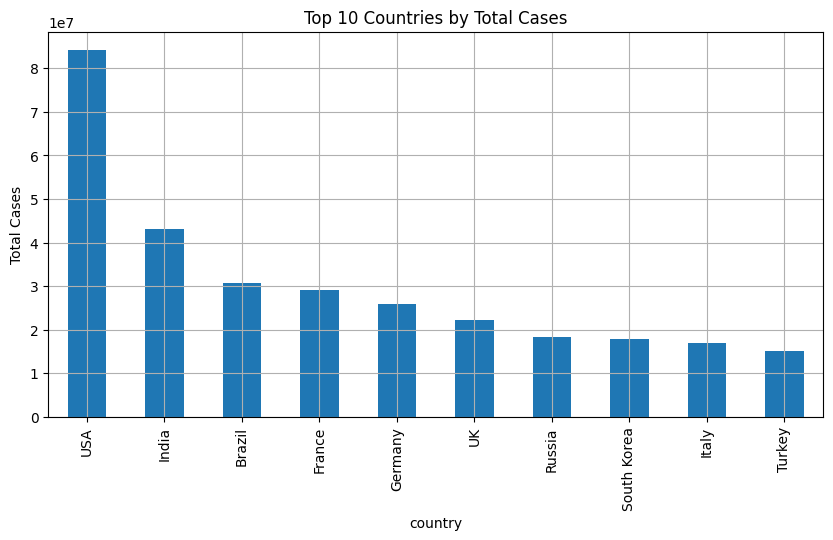

In [15]:
top_countries = df.groupby("country")["cumulative_total_cases"].max().sort_values(ascending=False).head(10)
top_countries.plot(kind="bar", figsize=(10,5), title="Top 10 Countries by Total Cases")
plt.ylabel("Total Cases")
plt.grid(True)
plt.show()


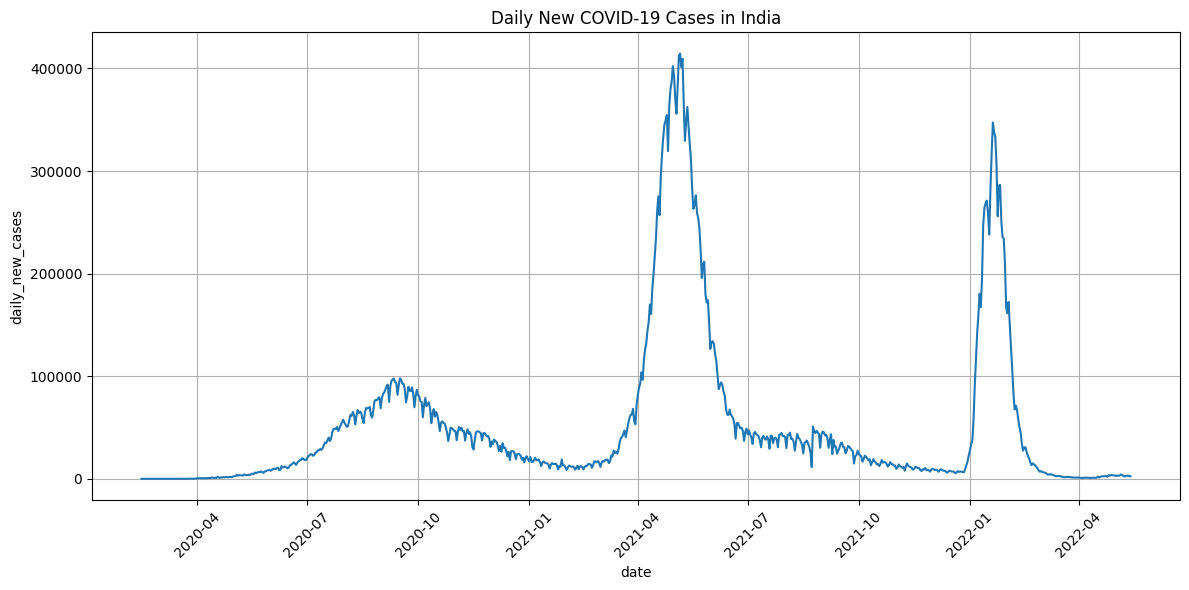

In [16]:
country_name = "India"  # Change as needed
country_df = df[df["country"] == country_name]

plt.figure(figsize=(12,6))
sns.lineplot(x="date", y="daily_new_cases", data=country_df)
plt.title(f"Daily New COVID-19 Cases in {country_name}")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [19]:
pip install streamlit


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.6 MB/s eta 0:00:00


In [20]:
import streamlit as st
import pandas as pd
import plotly.express as px

# Load data
@st.cache
def load_data():
    df = pd.read_csv("worldometer_coronavirus_daily_data.csv")
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    df["date"] = pd.to_datetime(df["date"])
    df = df.fillna(0)
    return df

df = load_data()

# Sidebar - Country selection
st.sidebar.title("Filters")
countries = df["country"].unique()
selected_country = st.sidebar.selectbox("Select a Country", countries)

# Filtered data
country_df = df[df["country"] == selected_country]

# Title
st.title("🌍 COVID-19 Country Dashboard")
st.markdown(f"Showing data for **{selected_country}**")

# Line Chart
fig = px.line(
    country_df,
    x="date",
    y="daily_new_cases",
    title=f"Daily New Cases in {selected_country}"
)
st.plotly_chart(fig)

# Metrics
latest = country_df.sort_values("date").iloc[-1]
st.metric("Cumulative Cases", int(latest["cumulative_total_cases"]))
st.metric("Active Cases", int(latest["active_cases"]))
st.metric("Total Deaths", int(latest["cumulative_total_deaths"]))


2025-05-11 18:41:48.857 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-11 18:41:49.588 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-05-11 18:41:49.594 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-11 18:41:49.597 
`st.cache` is deprecated and will be removed soon. Please use one of Streamlit's new
caching commands, `st.cache_data` or `st.cache_resource`. More information
[in our docs](https://docs.streamlit.io/develop/concepts/architecture/caching).

**Note**: The behavior of `st.cache` was updated in Streamlit 1.36 to the new caching
logic used by `st.cache_data` and `st.cache_resource`. This might lead to some problems
or unexpected behavior in certain edge cases.

2025-05-11 18:41:49.600 No runtime found, using MemoryCacheStorageManager
2025-05-11 18:41:49.603 No runtime found, using MemoryC

DeltaGenerator()